# Greedy Algorithms

Lab associated with Module 8: Greedy Algorithms

***

In [1]:
# The following lines are used to increase the width of cells to utilize more space on the screen 
from IPython.display import display, HTML  # IPython.core.display is deprecated
display(HTML("<style>.container { width:95% !important; }</style>"))

***

### Section 0: Imports

In [2]:
import numpy as np

In [3]:
import math

In [4]:
from IPython.display import Image
from graphviz import Digraph, Graph as GvGraph  # undirected drawings for the MST

In [5]:
import heapq
import itertools
import random
import time

***

### <font color='red'> Activity 1: Write code for creating a prefix tree for any arbitrary distribution, e.g., [A:45, B:13, C:12, D:16, E:9, F:5]. Your algorithm should return the prefix tree and should display the correct code for every alphabet.. </font>

In [6]:
class HuffmanNode:
    """One node of the prefix tree. Leaves carry a symbol, internal nodes carry only a frequency."""

    def __init__(self, freq, symbol=None, left=None, right=None):
        self.freq = freq
        self.symbol = symbol
        self.left = left
        self.right = right

    def is_leaf(self):
        return self.left is None and self.right is None

    def __repr__(self):
        return f"Leaf({self.symbol}:{self.freq})" if self.is_leaf() else f"Node({self.freq})"


def huffman(freq):
    """Build the Huffman prefix tree for a {symbol: frequency} distribution.

    Greedy step: pop the two lowest-frequency nodes, join them under a new parent
    whose frequency is their sum, push the parent back. The heap makes each step
    O(log n), so the whole build is O(n log n).
    """
    counter = itertools.count()          # tie-break so the heap never compares two HuffmanNodes
    heap = [(f, next(counter), HuffmanNode(f, s)) for s, f in freq.items()]
    heapq.heapify(heap)

    if len(heap) == 1:                   # one symbol: hang the single leaf off a root so its code is "0"
        f, _, leaf = heap[0]
        return HuffmanNode(f, left=leaf)

    while len(heap) > 1:
        f1, _, a = heapq.heappop(heap)   # least frequent
        f2, _, b = heapq.heappop(heap)   # second least frequent
        parent = HuffmanNode(f1 + f2, left=a, right=b)
        heapq.heappush(heap, (f1 + f2, next(counter), parent))

    return heap[0][2]


def huffman_codes(root, prefix="", codes=None):
    """Walk the tree, 0 for left and 1 for right, and collect the code at each leaf."""
    if codes is None:
        codes = {}
    if root.is_leaf():
        codes[root.symbol] = prefix
        return codes
    if root.left:
        huffman_codes(root.left, prefix + "0", codes)
    if root.right:
        huffman_codes(root.right, prefix + "1", codes)
    return codes


def is_prefix_free(codes):
    """No code may be a prefix of another code."""
    cs = list(codes.values())
    return all(not b.startswith(a) for a in cs for b in cs if a != b)


def encode(text, codes):
    return "".join(codes[ch] for ch in text)


def decode(bits, root):
    out, node = [], root
    for b in bits:
        node = node.left if b == "0" else node.right
        if node.is_leaf():
            out.append(node.symbol)
            node = root
    return "".join(out)

In [7]:
def show_huffman(freq, title=""):
    """Build the tree for freq, print every code, and return the tree."""
    root = huffman(freq)
    codes = huffman_codes(root)
    total = sum(freq.values())
    cost = sum(freq[s] * len(codes[s]) for s in freq)          # weighted path length
    fixed = math.ceil(math.log2(len(freq))) if len(freq) > 1 else 1
    print(f"=== {title or freq} ===")
    print(f"{'sym':>4} {'freq':>6} {'code':>10} {'len':>4}")
    for s in sorted(freq, key=lambda s: (-freq[s], s)):
        print(f"{s!r:>4} {freq[s]:>6} {codes[s]:>10} {len(codes[s]):>4}")
    print(f"prefix-free: {is_prefix_free(codes)}")
    print(f"total bits: {cost}  (fixed-length would be {fixed} x {total} = {fixed * total})")
    print(f"average bits per symbol: {cost / total:.3f}")
    print()
    return root, codes


def draw_huffman(root):
    """Render the prefix tree with graphviz. Leaves show symbol:freq, internal nodes show freq."""
    dot = Digraph()
    dot.attr("node", shape="circle", fontsize="11")
    ids = itertools.count()

    def walk(node, name):
        if node.is_leaf():
            dot.node(name, f"{node.symbol}:{node.freq}", shape="box", style="filled", fillcolor="#ffe0b2")
        else:
            dot.node(name, str(node.freq))
            for child, bit in ((node.left, "0"), (node.right, "1")):
                if child is None:
                    continue
                cname = str(next(ids))
                walk(child, cname)
                dot.edge(name, cname, label=bit)

    walk(root, "root")
    return dot

=== Task example ===
 sym   freq       code  len
 'A'     45          0    1
 'D'     16        111    3
 'B'     13        101    3
 'C'     12        100    3
 'E'      9       1101    4
 'F'      5       1100    4
prefix-free: True
total bits: 224  (fixed-length would be 3 x 100 = 300)
average bits per symbol: 2.240



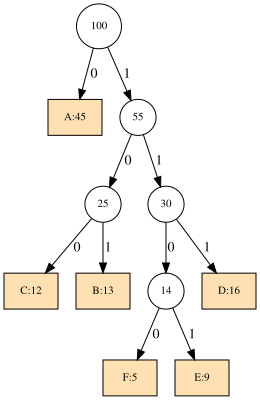

In [8]:
# Problem 1: the example from the task sheet (and CLRS 16.3)
freq1 = {'A': 45, 'B': 13, 'C': 12, 'D': 16, 'E': 9, 'F': 5}
tree1, codes1 = show_huffman(freq1, "Task example")
draw_huffman(tree1)

In [9]:
# Problem 2: frequencies counted from a real sentence, then a round trip through encode/decode
text = "greedy algorithms make the locally best choice and never look back"
freq2 = {ch: text.count(ch) for ch in set(text)}
tree2, codes2 = show_huffman(freq2, "Counted from a sentence")

bits = encode(text, codes2)
print("encoded bits:", len(bits), "  ASCII bits:", 8 * len(text))
print("round trip ok:", decode(bits, tree2) == text)

=== Counted from a sentence ===
 sym   freq       code  len
 ' '     10        101    3
 'e'      8        010    3
 'a'      5       1101    4
 'l'      5       1110    4
 'o'      5       1100    4
 'c'      4       0110    4
 'h'      3       0001    4
 'k'      3      11111    5
 'r'      3       0000    4
 't'      3       0010    4
 'b'      2      10010    5
 'd'      2      10000    5
 'g'      2      11110    5
 'i'      2      01111    5
 'm'      2      10011    5
 'n'      2      00111    5
 's'      2      10001    5
 'y'      2      01110    5
 'v'      1      00110    5
prefix-free: True
total bits: 266  (fixed-length would be 5 x 66 = 330)
average bits per symbol: 4.030

encoded bits: 266   ASCII bits: 528
round trip ok: True


=== Uniform, 8 symbols ===
 sym   freq       code  len
 'A'     10        000    3
 'B'     10        001    3
 'C'     10        010    3
 'D'     10        011    3
 'E'     10        100    3
 'F'     10        101    3
 'G'     10        110    3
 'H'     10        111    3
prefix-free: True
total bits: 240  (fixed-length would be 3 x 80 = 240)
average bits per symbol: 3.000



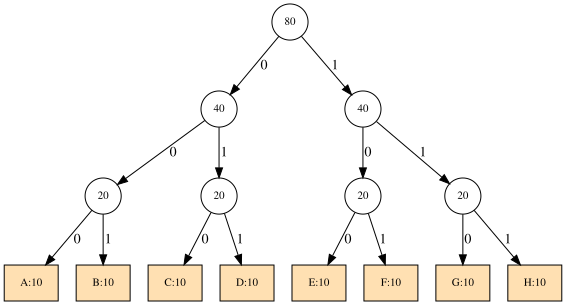

In [10]:
# Problem 3: uniform distribution over 8 symbols. Every code should come out the same length (3 bits),
# so Huffman gives nothing over a fixed-length code here.
freq3 = {s: 10 for s in "ABCDEFGH"}
tree3, codes3 = show_huffman(freq3, "Uniform, 8 symbols")
draw_huffman(tree3)

=== Fibonacci frequencies ===
 sym   freq       code  len
 'g'     13          0    1
 'f'      8         10    2
 'e'      5        110    3
 'd'      3       1110    4
 'c'      2      11110    5
 'a'      1     111110    6
 'b'      1     111111    6
prefix-free: True
total bits: 78  (fixed-length would be 3 x 33 = 99)
average bits per symbol: 2.364



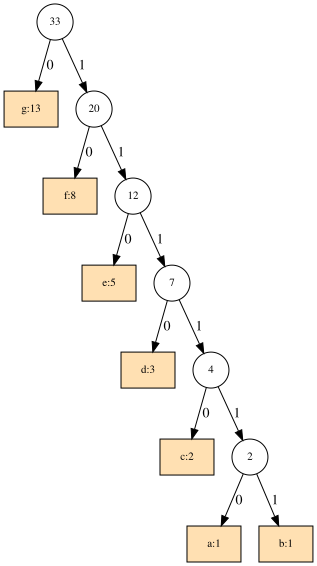

In [11]:
# Problem 4: Fibonacci frequencies. Every merge picks the newest parent plus the next leaf,
# so the tree degenerates into a chain and the rarest symbol gets a 6 bit code.
freq4 = {'a': 1, 'b': 1, 'c': 2, 'd': 3, 'e': 5, 'f': 8, 'g': 13}
tree4, codes4 = show_huffman(freq4, "Fibonacci frequencies")
draw_huffman(tree4)

In [12]:
# Problem 5: approximate English letter frequencies (per 1000 letters)
freq5 = {'e': 127, 't': 91, 'a': 82, 'o': 75, 'i': 70, 'n': 67, 's': 63, 'h': 61, 'r': 60,
         'd': 43, 'l': 40, 'c': 28, 'u': 28, 'm': 24, 'w': 24, 'f': 22, 'g': 20, 'y': 20,
         'p': 19, 'b': 15, 'v': 10, 'k': 8, 'j': 2, 'x': 2, 'q': 1, 'z': 1}
tree5, codes5 = show_huffman(freq5, "English letter frequencies")

=== English letter frequencies ===
 sym   freq       code  len
 'e'    127        100    3
 't'     91        000    3
 'a'     82       1110    4
 'o'     75       1101    4
 'i'     70       1011    4
 'n'     67       1010    4
 's'     63       0111    4
 'h'     61       0110    4
 'r'     60       0101    4
 'd'     43      11111    5
 'l'     40      11001    5
 'c'     28      01000    5
 'u'     28      01001    5
 'm'     24      00101    5
 'w'     24      00110    5
 'f'     22      00100    5
 'g'     20     111100    6
 'y'     20     111101    6
 'p'     19     110001    6
 'b'     15     110000    6
 'v'     10     001110    6
 'k'      8    0011111    7
 'j'      2  001111010    9
 'x'      2  001111011    9
 'q'      1  001111000    9
 'z'      1  001111001    9
prefix-free: True
total bits: 4225  (fixed-length would be 5 x 1003 = 5015)
average bits per symbol: 4.212



In [13]:
# Edge cases: a single symbol still needs one bit, and two symbols get one bit each
show_huffman({'A': 100}, "Single symbol")
show_huffman({'A': 70, 'B': 30}, "Two symbols");

=== Single symbol ===
 sym   freq       code  len
 'A'    100          0    1
prefix-free: True
total bits: 100  (fixed-length would be 1 x 100 = 100)
average bits per symbol: 1.000

=== Two symbols ===
 sym   freq       code  len
 'A'     70          1    1
 'B'     30          0    1
prefix-free: True
total bits: 100  (fixed-length would be 1 x 100 = 100)
average bits per symbol: 1.000



***

###  Prim's Algorithm

Graph's Preliminaries

In [14]:
from graph import *

In [15]:
G = Graph()

for i in ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']:
    G.addVertex( Node(i) )

In [16]:
V = G.vertices

#0, 1, 2, 3, 4, 5, 6, 7, 8
#A, B, C, D, E, F, G, H, I

G.addBiEdge( V[0], V[1], 4)

G.addBiEdge( V[0], V[7] , 8)

G.addBiEdge( V[1], V[7], 11)

G.addBiEdge( V[1], V[2], 8)

G.addBiEdge( V[2], V[3], 7)

G.addBiEdge( V[3], V[4], 9)

G.addBiEdge( V[3], V[5], 14 )

G.addBiEdge( V[4], V[5], 10 )

G.addBiEdge( V[2], V[5], 4 )

G.addBiEdge( V[2], V[8], 2 )

G.addBiEdge( V[5], V[6], 2 )

G.addBiEdge( V[6], V[7], 1 )

G.addBiEdge( V[6], V[8], 6 )

G.addBiEdge( V[7], V[8], 7 )


In [17]:
print(G)

Graph with:
	 Vertices:
	A,B,C,D,E,F,G,H,I,
	 Edges:
	(A,(B, 4)) (A,(H, 8)) (B,(A, 4)) (B,(H, 11)) (B,(C, 8)) (C,(B, 8)) (C,(D, 7)) (C,(F, 4)) (C,(I, 2)) (D,(C, 7)) (D,(E, 9)) (D,(F, 14)) (E,(D, 9)) (E,(F, 10)) (F,(D, 14)) (F,(E, 10)) (F,(C, 4)) (F,(G, 2)) (G,(F, 2)) (G,(H, 1)) (G,(I, 6)) (H,(A, 8)) (H,(B, 11)) (H,(G, 1)) (H,(I, 7)) (I,(C, 2)) (I,(G, 6)) (I,(H, 7)) 



In [18]:
def draw_mst(G, mst_edges, title=""):
    """Undirected drawing of G with the MST edges in orange. Works for any list of (u, v) node pairs."""
    chosen = {frozenset((u, v)) for u, v in mst_edges}
    dot = GvGraph(engine="neato")
    dot.attr(label=title, labelloc="t", overlap="false", splines="true")
    dot.attr("node", shape="circle", fontsize="11")
    seen = set()
    for u in G.vertices:
        dot.node(str(u))
        for v, wt in u.getOutNeighborsWithWeights():
            key = frozenset((u, v))
            if key in seen:
                continue
            seen.add(key)
            if key in chosen:
                dot.edge(str(u), str(v), label=str(wt), color="darkorange", penwidth="3", fontcolor="darkorange")
            else:
                dot.edge(str(u), str(v), label=str(wt), color="gray60", fontcolor="gray40")
    return dot

This is what we had in the lectures as the slow implementation of Prim's Algorithm

In [19]:
# G is graph
# s is the node to start

def slowPrim(G, s):
    
    # first, find the lightest edge leaving s
    bestWt = np.inf
    bestu = None
    
    for u,wt in s.getOutNeighborsWithWeights():
        
        if wt < bestWt:
            bestWt = wt
            bestu = u
    
    MST = [ (s, bestu) ]
    verticesVisited = [s,bestu]
    
    while len(verticesVisited) < len(G.vertices): # danger! this will loop forever if the graph isn't connected...
        
        # find the lightest edge (x,v) so that x has been visited and v hasn't.
        bestWt = np.inf
        bestv = None
        bestx = None
        
        for x in verticesVisited:
            for v,wt in x.getOutNeighborsWithWeights():
                
                if v in verticesVisited:
                    continue
                
                if wt < bestWt:
                    bestWt = wt
                    bestv = v
                    bestx = x
                    
        MST.append((bestx,bestv))
        verticesVisited.append(bestv)
    
    return MST

A B
A H
H G
G F
F C
C I
C D
D E
total weight: 37


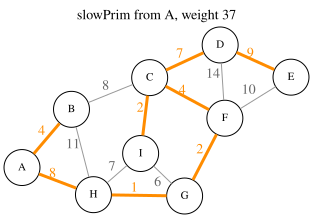

In [20]:
T = slowPrim(G, G.vertices[0])

for x,y in T:
    print(x,y)

print("total weight:", sum(wt for u, v in T for n, wt in u.getOutNeighborsWithWeights() if n is v))
draw_mst(G, T, "slowPrim from A, weight 37")

Okay, it seems to be working fine, but as we discussed, will be quite slow. Let us see if we can work on the faster version of the code as:

### <font color='red'> Activity 2: In lights of Prim's Algorithm above, write an efficient implementation based on our discussions in the Seminar/Lecture. </font>

In [21]:
def prim(G, s):
    """Prim's algorithm with a binary heap, in the shape of Dijkstra from Module 6.

    key[v]    lightest edge seen so far from the growing tree to v (the 'distance' map)
    parent[v] the tree-side endpoint of that edge
    visited   vertices already in the tree
    heap      (key, name, vertex) triples; the name is only there so two equal keys never
              fall through to comparing Node objects, which have no ordering.

    Stale heap entries are skipped rather than decrease-keyed, which heapq cannot do.
    Every edge is pushed at most once per direction, so the heap holds O(m) entries and
    the whole run is O(m log n).
    """
    key = {v: np.inf for v in G.vertices}
    parent = {v: None for v in G.vertices}
    visited = set()
    MST = []

    key[s] = 0
    heap = [(0, s.value, s)]

    while heap:
        k, _, u = heapq.heappop(heap)
        if u in visited:                       # stale entry, a lighter edge already brought u in
            continue
        visited.add(u)
        if parent[u] is not None:
            MST.append((parent[u], u))

        for v, wt in u.getOutNeighborsWithWeights():
            if v not in visited and wt < key[v]:   # relaxation step: edge weight, not path length
                key[v] = wt
                parent[v] = u
                heapq.heappush(heap, (wt, v.value, v))

    return MST

A B
B C
C I
C F
F G
G H
C D
D E
total weight: 37


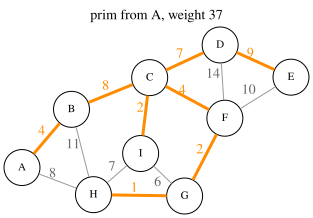

In [22]:
T = prim(G, G.vertices[0])

for x,y in T:
    print(x,y)

print("total weight:", sum(wt for u, v in T for n, wt in u.getOutNeighborsWithWeights() if n is v))
draw_mst(G, T, "prim from A, weight 37")

### <font color='red'> Performance comparison: slowPrim against prim on large random graphs </font>

Both functions below are the two algorithms above with one counter added, so I can report the number of edge-weight comparisons as well as wall-clock time. The comparison count is deterministic for a given seed; the timings depend on the machine.

In [23]:
def slowPrim_counted(G, s):
    """slowPrim with a comparison counter. Logic is unchanged."""
    comparisons = 0
    bestWt, bestu = np.inf, None
    for u, wt in s.getOutNeighborsWithWeights():
        comparisons += 1
        if wt < bestWt:
            bestWt, bestu = wt, u
    MST = [(s, bestu)]
    verticesVisited = [s, bestu]
    visitedSet = {s, bestu}                    # set for O(1) membership; the list version is O(n) per check
    while len(verticesVisited) < len(G.vertices):
        bestWt, bestv, bestx = np.inf, None, None
        for x in verticesVisited:
            for v, wt in x.getOutNeighborsWithWeights():
                if v in visitedSet:
                    continue
                comparisons += 1
                if wt < bestWt:
                    bestWt, bestv, bestx = wt, v, x
        MST.append((bestx, bestv))
        verticesVisited.append(bestv)
        visitedSet.add(bestv)
    return MST, comparisons


def prim_counted(G, s):
    """prim with a comparison counter. Logic is unchanged."""
    comparisons = 0
    key = {v: np.inf for v in G.vertices}
    parent = {v: None for v in G.vertices}
    visited = set()
    MST = []
    key[s] = 0
    heap = [(0, s.value, s)]
    while heap:
        k, _, u = heapq.heappop(heap)
        if u in visited:
            continue
        visited.add(u)
        if parent[u] is not None:
            MST.append((parent[u], u))
        for v, wt in u.getOutNeighborsWithWeights():
            if v not in visited:
                comparisons += 1
                if wt < key[v]:
                    key[v] = wt
                    parent[v] = u
                    heapq.heappush(heap, (wt, v.value, v))
    return MST, comparisons


def random_connected_graph(n, m, seed=0, max_wt=100):
    """Undirected weighted graph on n vertices with m edges. A random spanning tree goes in first
    so the graph is always connected (slowPrim loops forever otherwise), then random extra edges."""
    rng = random.Random(seed)
    G = Graph()
    for i in range(n):
        G.addVertex(Node(i))
    V = G.vertices
    edges = set()
    order = list(range(n))
    rng.shuffle(order)
    for i in range(1, n):                              # spanning tree: attach each vertex to an earlier one
        a, b = order[i], order[rng.randrange(i)]
        edges.add((min(a, b), max(a, b)))
    while len(edges) < m:
        a, b = rng.randrange(n), rng.randrange(n)
        if a != b:
            edges.add((min(a, b), max(a, b)))
    for a, b in edges:
        G.addBiEdge(V[a], V[b], rng.randint(1, max_wt))
    return G


def mst_weight(T):
    return sum(wt for u, v in T for n, wt in u.getOutNeighborsWithWeights() if n is v)

In [24]:
print(f"{'n':>6} {'m':>7} | {'slowPrim ms':>12} {'comparisons':>12} | {'prim ms':>9} {'comparisons':>12} | {'speedup':>8} {'same weight':>12}")
print("-" * 100)
results = []
for n in [100, 200, 400, 800, 1600]:
    m = 5 * n
    G_big = random_connected_graph(n, m, seed=n)
    s = G_big.vertices[0]

    t0 = time.perf_counter()
    T_slow, c_slow = slowPrim_counted(G_big, s)
    t_slow = (time.perf_counter() - t0) * 1000

    t0 = time.perf_counter()
    T_fast, c_fast = prim_counted(G_big, s)
    t_fast = (time.perf_counter() - t0) * 1000

    same = mst_weight(T_slow) == mst_weight(T_fast) and len(T_slow) == len(T_fast) == n - 1
    results.append((n, m, t_slow, c_slow, t_fast, c_fast))
    print(f"{n:>6} {m:>7} | {t_slow:>12.2f} {c_slow:>12,} | {t_fast:>9.2f} {c_fast:>12,} | {t_slow / t_fast:>7.1f}x {str(same):>12}")

     n       m |  slowPrim ms  comparisons |   prim ms  comparisons |  speedup  same weight
----------------------------------------------------------------------------------------------------
   100     500 |         1.86       14,274 |      0.23          500 |     8.0x         True
   200    1000 |         8.01       58,404 |      0.41        1,000 |    19.7x         True


   400    2000 |        35.83      231,810 |      0.91        2,000 |    39.2x         True


   800    4000 |       183.28      906,463 |      2.48        4,000 |    74.0x         True

  1600    8000 |       799.16    3,619,090 |      5.37        8,000 |   148.8x         True


slowPrim rescans every edge out of every visited vertex on every iteration, so its comparison count grows like $n \cdot m$. prim examines each edge exactly once, from whichever endpoint enters the tree first (the other endpoint is already visited by the time the edge is seen again), so its count is exactly $m$, with the heap adding a $\log n$ factor per push and pop. Doubling $n$ (with $m = 5n$) quadruples slowPrim's work and roughly doubles prim's, which is what the two comparison columns show.

***

### <font color='red'> Activity 3: Greedy coin change. Take the largest coin that fits until the amount is reached, compare against dynamic programming, and work out when the greedy answer is wrong. </font>

In [25]:
def greedy_coin_change(coins, amount):
    """Largest coin that fits, repeatedly. Returns the list of coins used, or -1 if it gets stuck."""
    change = []
    remaining = amount
    for c in sorted(coins, reverse=True):
        while c <= remaining:
            change.append(c)
            remaining -= c
    return change if remaining == 0 else -1


def dp_coin_change(coins, amount):
    """Fewest coins by bottom-up DP (Module 7). Returns the coin list, or -1 if the amount is unreachable."""
    K = [math.inf] * (amount + 1)
    K[0] = 0
    pick = [None] * (amount + 1)
    for x in range(1, amount + 1):
        for c in coins:
            if c <= x and K[x - c] + 1 < K[x]:
                K[x] = K[x - c] + 1
                pick[x] = c
    if K[amount] == math.inf:
        return -1
    change, x = [], amount
    while x > 0:
        change.append(pick[x])
        x -= pick[x]
    return change


def count(result):
    return len(result) if result != -1 else -1

In [26]:
cases = [
    ([1, 5, 10, 25],      63,  "US coins"),
    ([5, 10, 20, 50, 100, 200], 385, "Australian cents"),
    ([1, 2, 5, 10, 20, 50], 99, "Euro-style"),
    ([1, 3, 4],            6,  "greedy takes 4 first"),
    ([1, 5, 10, 25, 30],   50, "extra 30 cent coin"),
    ([9, 6, 5, 1],         11, "CLRS-style counterexample"),
    ([1, 10, 25],          30, "no 5 cent coin"),
    ([2, 5],               6,  "greedy gets stuck"),
    ([4, 6, 10],           7,  "genuinely unreachable"),
    ([1, 5, 10],           0,  "zero amount"),
]

print(f"{'coins':<24} {'amount':>6} | {'greedy':<22} {'#':>3} | {'DP':<22} {'#':>3} | verdict")
print("-" * 100)
for coins, amount, note in cases:
    g = greedy_coin_change(coins, amount)
    d = dp_coin_change(coins, amount)
    if g == -1 and d == -1:
        verdict = "both unreachable"
    elif g == -1:
        verdict = "greedy WRONG: stuck, DP found one"
    elif count(g) == count(d):
        verdict = "greedy optimal"
    else:
        verdict = f"greedy WRONG: {count(g)} vs {count(d)} coins"
    print(f"{str(coins):<24} {amount:>6} | {str(g):<22} {count(g):>3} | {str(d):<22} {count(d):>3} | {verdict}   ({note})")

coins                    amount | greedy                   # | DP                       # | verdict
----------------------------------------------------------------------------------------------------
[1, 5, 10, 25]               63 | [25, 25, 10, 1, 1, 1]    6 | [1, 1, 1, 10, 25, 25]    6 | greedy optimal   (US coins)
[5, 10, 20, 50, 100, 200]    385 | [200, 100, 50, 20, 10, 5]   6 | [5, 10, 20, 50, 100, 200]   6 | greedy optimal   (Australian cents)
[1, 2, 5, 10, 20, 50]        99 | [50, 20, 20, 5, 2, 2]    6 | [2, 2, 5, 20, 20, 50]    6 | greedy optimal   (Euro-style)
[1, 3, 4]                     6 | [4, 1, 1]                3 | [3, 3]                   2 | greedy WRONG: 3 vs 2 coins   (greedy takes 4 first)
[1, 5, 10, 25, 30]           50 | [30, 10, 10]             3 | [25, 25]                 2 | greedy WRONG: 3 vs 2 coins   (extra 30 cent coin)
[9, 6, 5, 1]                 11 | [9, 1, 1]                3 | [6, 5]                   2 | greedy WRONG: 3 vs 2 coins   (CLRS-style cou

In [27]:
def greedy_is_optimal(coins, upto=None):
    """Brute check: does greedy match DP for every amount from 1 to upto?
    Kozen and Zaks showed a counterexample, if one exists, appears below coin_max + coin_second_max,
    so checking up to that bound decides the whole system."""
    cs = sorted(coins)
    if upto is None:
        upto = cs[-1] + cs[-2]
    for a in range(1, upto + 1):
        g, d = greedy_coin_change(coins, a), dp_coin_change(coins, a)
        if count(g) != count(d):
            return False, a
    return True, None

for coins in [[1, 5, 10, 25], [5, 10, 20, 50, 100, 200], [1, 2, 5, 10, 20, 50], [1, 3, 4], [1, 5, 10, 25, 30], [9, 6, 5, 1], [1, 10, 25]]:
    ok, a = greedy_is_optimal(coins)
    print(f"{str(coins):<28} canonical: {ok!s:<5}" + ("" if ok else f"  first failing amount: {a}"))

[1, 5, 10, 25]               canonical: True 
[5, 10, 20, 50, 100, 200]    canonical: True 
[1, 2, 5, 10, 20, 50]        canonical: True 
[1, 3, 4]                    canonical: False  first failing amount: 6
[1, 5, 10, 25, 30]           canonical: False  first failing amount: 50
[9, 6, 5, 1]                 canonical: False  first failing amount: 11
[1, 10, 25]                  canonical: False  first failing amount: 30


The greedy rule works on every coin system in daily use because each denomination is large enough to absorb the coins below it. The rule breaks when a mid-sized coin exists that the largest coin cannot replace efficiently, like the 30 in $\{1, 5, 10, 25, 30\}$ or the 3 and 4 in $\{1, 3, 4\}$, or when the system has no 1 so greedy can dead-end on a remainder that a different first choice would have avoided. A quick brute-force check up to the sum of the two largest coins settles whether a given system is safe to use greedily.

***